In [2]:
from PIL import Image
import torch
from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES
import numpy as np

from inference_utils.inference import interactive_infer_image
from inference_utils.output_processing import check_mask_stats, dice_batch
from inference_utils.processing_utils import read_nifti, read_nifti_only, process_intensity_image, resize_to_original

import os
from matplotlib import pyplot as plt

import json
import nibabel as nib



C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Deformable Transformer Encoder is not available.


C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\kornia\feature\lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [ ]:
import huggingface_hub

HF_TOKEN = ''

huggingface_hub.login(HF_TOKEN)

### Model Setup

In [3]:
opt = load_opt_from_config_files(["configs/biomedparse_inference.yaml"])
opt = init_distributed(opt)

# Load model from pretrained weights
pretrained_pth = 'pretrained/biomed_parse.pt'
pretrained_pth = 'hf_hub:microsoft/BiomedParse'

model = BaseModel(opt, build_model(opt)).from_pretrained(pretrained_pth).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(BIOMED_CLASSES + ["background"], is_eval=True)


C:\Users\Toni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
$UNUSED$ criterion.empty_weight, Ckpt Shape: torch.Size([17])


### Utility Functions

In [4]:
def plot_segmentation_masks(original_image, segmentation_masks, texts, rotate=0):
    ''' Plot a list of segmentation mask over an image.
    '''
    original_image = original_image[:, :, :3]
    fig, ax = plt.subplots(1, len(segmentation_masks) + 1, figsize=(10, 5))
    ax[0].imshow(np.rot90(original_image, rotate), cmap='gray')
    ax[0].set_title('Original Image')
    # grid off
    for a in ax:
        a.axis('off')

    for i, mask in enumerate(segmentation_masks):
        
        ax[i+1].set_title(texts[i])
        mask_temp = original_image.copy()
        mask_temp[mask > 0.5] = [255, 0, 0]
        mask_temp[mask <= 0.5] = [0, 0, 0, ]
        ax[i+1].imshow(np.rot90(mask_temp, rotate), alpha=0.9)
        ax[i+1].imshow(np.rot90(original_image, rotate), cmap='gray', alpha=0.5)
        
    
    plt.show()

In [5]:
!pip install pydicom nibabel SimpleITK


def inference_nifti(file_path, text_prompts, is_CT, slice_idx, site=None, HW_index=(0, 1), channel_idx=None, rotate=0):
    # image = read_nifti(file_path, is_CT,slice_idx, site=site, 
    #                 HW_index=HW_index, channel_idx=channel_idx)
    
    n_scans = 1
    for scan in range(n_scans):
        image, nii = read_nifti_only(file_path,  HW_index=(0, 1))
        test_3D = np.empty((1, image.shape[0], image.shape[1]))
        print(f"Current scan is of shape {image.shape}")
        for slice_iter in range(image.shape[2]):
        # for slice_iter in range(10):

            image_array = process_intensity_image(image[: ,: , slice_iter], is_CT, site)

            pred_mask = interactive_infer_image(model, Image.fromarray(image_array), text_prompts)

            # im = Image.fromarray(image_array.astype(np.uint8))
            # im.save(f"pred_masks\og{slice_iter}.png")

            # im = Image.fromarray((pred_mask[0]*255).astype(np.uint8))
            # im.save(f"pred_masks\slice_{slice_iter}.png")

            # resize to original size
            resize_image = resize_to_original(pred_mask, image.shape[0], image.shape[1])

            im = Image.fromarray((resize_image[0]*255).astype(np.uint8))
            im.save(f"pred_masks\slice_{slice_iter}.png")

            test_3D = np.vstack((test_3D, resize_image))

            print(f"3D shape: {test_3D.shape}")

        # # Plot feature over image
        # plot_segmentation_masks(image, pred_mask, text_prompts, rotate=rotate)
        test_3D = np.delete(test_3D, (0), axis=0)

        final_img = nib.Nifti1Image(test_3D.transpose(1,2,0), nii)
        nib.save(final_img, f'test_{scan}.nii.gz')
    
    return test_3D



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\Toni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
image_path = 'examples//NYU_0036_0000.nii.gz'
text_prompts = ['pancreas']

# image =  inference_nifti(image_path, text_prompts,slice_idx=None, is_CT=False, site='pancreas', channel_idx=None, rotate=3)

In [3]:
path = 'examples//NYU_0036.nii.gz'
gt_segmentation, nii = read_nifti_only(path,  HW_index=(0, 1))

path_pred = 'test_0.nii.gz'
pred_segmentation, nii = read_nifti_only(path_pred,  HW_index=(0, 1))


value = dice_batch(torch.tensor(gt_segmentation.astype(np.uint8).transpose(2, 1, 0)), torch.tensor(pred_segmentation.astype(np.uint8).transpose(2, 1, 0)))

In [8]:
print(f"3D_dice: {value.mean():05.3f}")  

3D_dice: 0.000


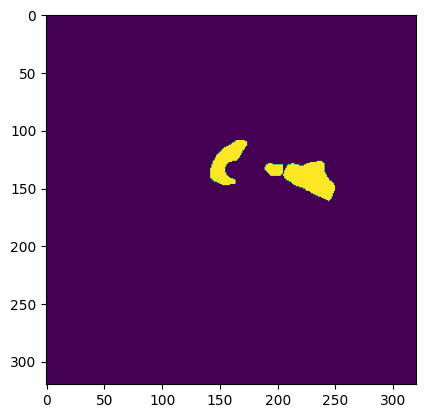

In [9]:
imgplot = plt.imshow(gt_segmentation.transpose(2, 1, 0)[20])
plt.show()

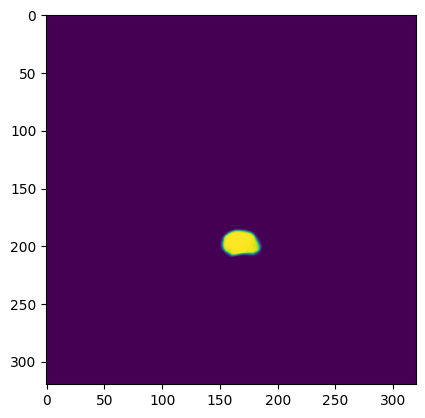

In [10]:
imgplot = plt.imshow( pred_segmentation.transpose(2, 1, 0)[20])
plt.show()